<a href="https://colab.research.google.com/github/AHMEDVALL70/ahmed-vall-cv/blob/main/Handwritten_Digits_Project_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


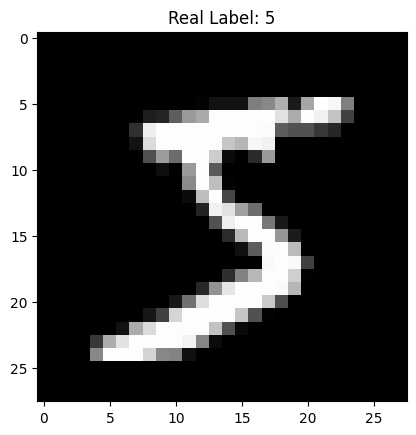

عدد صور التدريب: 60000


In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. تحميل مجموعة بيانات MNIST
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2. تطبيع البيانات (تحويل قيم البكسلات من 0-255 إلى 0-1) لسهولة التدريب
x_train, x_test = x_train / 255.0, x_test / 255.0

# 3. عرض أول صورة في المجموعة لنتأكد من البيانات
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Real Label: {y_train[0]}")
plt.show()

print(f"عدد صور التدريب: {len(x_train)}")

In [2]:
# 1. بناء هيكل الشبكة العصبية
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)), # تحويل الصورة لخط مستقيم
  tf.keras.layers.Dense(128, activation='relu'), # الطبقة الذكية
  tf.keras.layers.Dropout(0.2),                 # لمنع الحفظ الأعمى (Overfitting)
  tf.keras.layers.Dense(10, activation='softmax') # النتائج النهائية (10 أرقام)
])

# 2. إعدادات التعلم
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 3. التدريب (Training) - سنكرر العملية 5 مرات
print("بدء عملية التدريب...")
model.fit(x_train, y_train, epochs=5)

# 4. تقييم الدقة على بيانات لم يراها النموذج من قبل
loss, accuracy = model.evaluate(x_test, y_test)
print(f"\nدقة النموذج النهائية: {accuracy*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


بدء عملية التدريب...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9149 - loss: 0.2949
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9581 - loss: 0.1421
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9673 - loss: 0.1077
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9717 - loss: 0.0902
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9755 - loss: 0.0768
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9761 - loss: 0.0796

دقة النموذج النهائية: 97.61%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


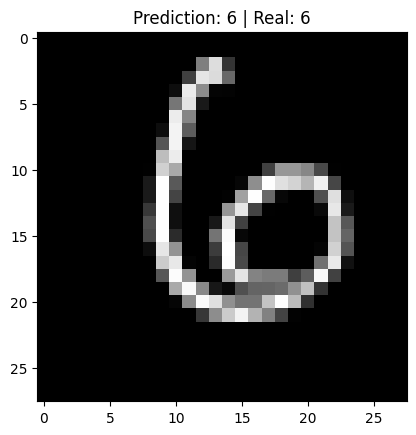

In [3]:
import numpy as np

# 1. اختر رقم صورة عشوائي من بيانات الاختبار (مثلاً الصورة رقم 100)
index = 100
prediction = model.predict(x_test[index:index+1])

# 2. عرض النتيجة
predicted_label = np.argmax(prediction)
true_label = y_test[index]

plt.imshow(x_test[index], cmap='gray')
plt.title(f"Prediction: {predicted_label} | Real: {true_label}")
plt.show()